In [1]:
import geopandas as gpd
import fiona

gdb_path = r"../../Data/Google Earth Engine/HydroRIVERS_v10_as.gdb/HydroRIVERS_v10_as.gdb"

In [2]:
layers = fiona.listlayers(gdb_path)
print(layers)

['HydroRIVERS_v10_as']


In [3]:
rivers = gpd.read_file(
    gdb_path,
    layer=layers[0]
)
print(rivers.columns)

Index(['HYRIV_ID', 'NEXT_DOWN', 'MAIN_RIV', 'LENGTH_KM', 'DIST_DN_KM',
       'DIST_UP_KM', 'CATCH_SKM', 'UPLAND_SKM', 'ENDORHEIC', 'DIS_AV_CMS',
       'ORD_STRA', 'ORD_CLAS', 'ORD_FLOW', 'HYBAS_L12', 'Shape_Length',
       'geometry'],
      dtype='object')


<Axes: >

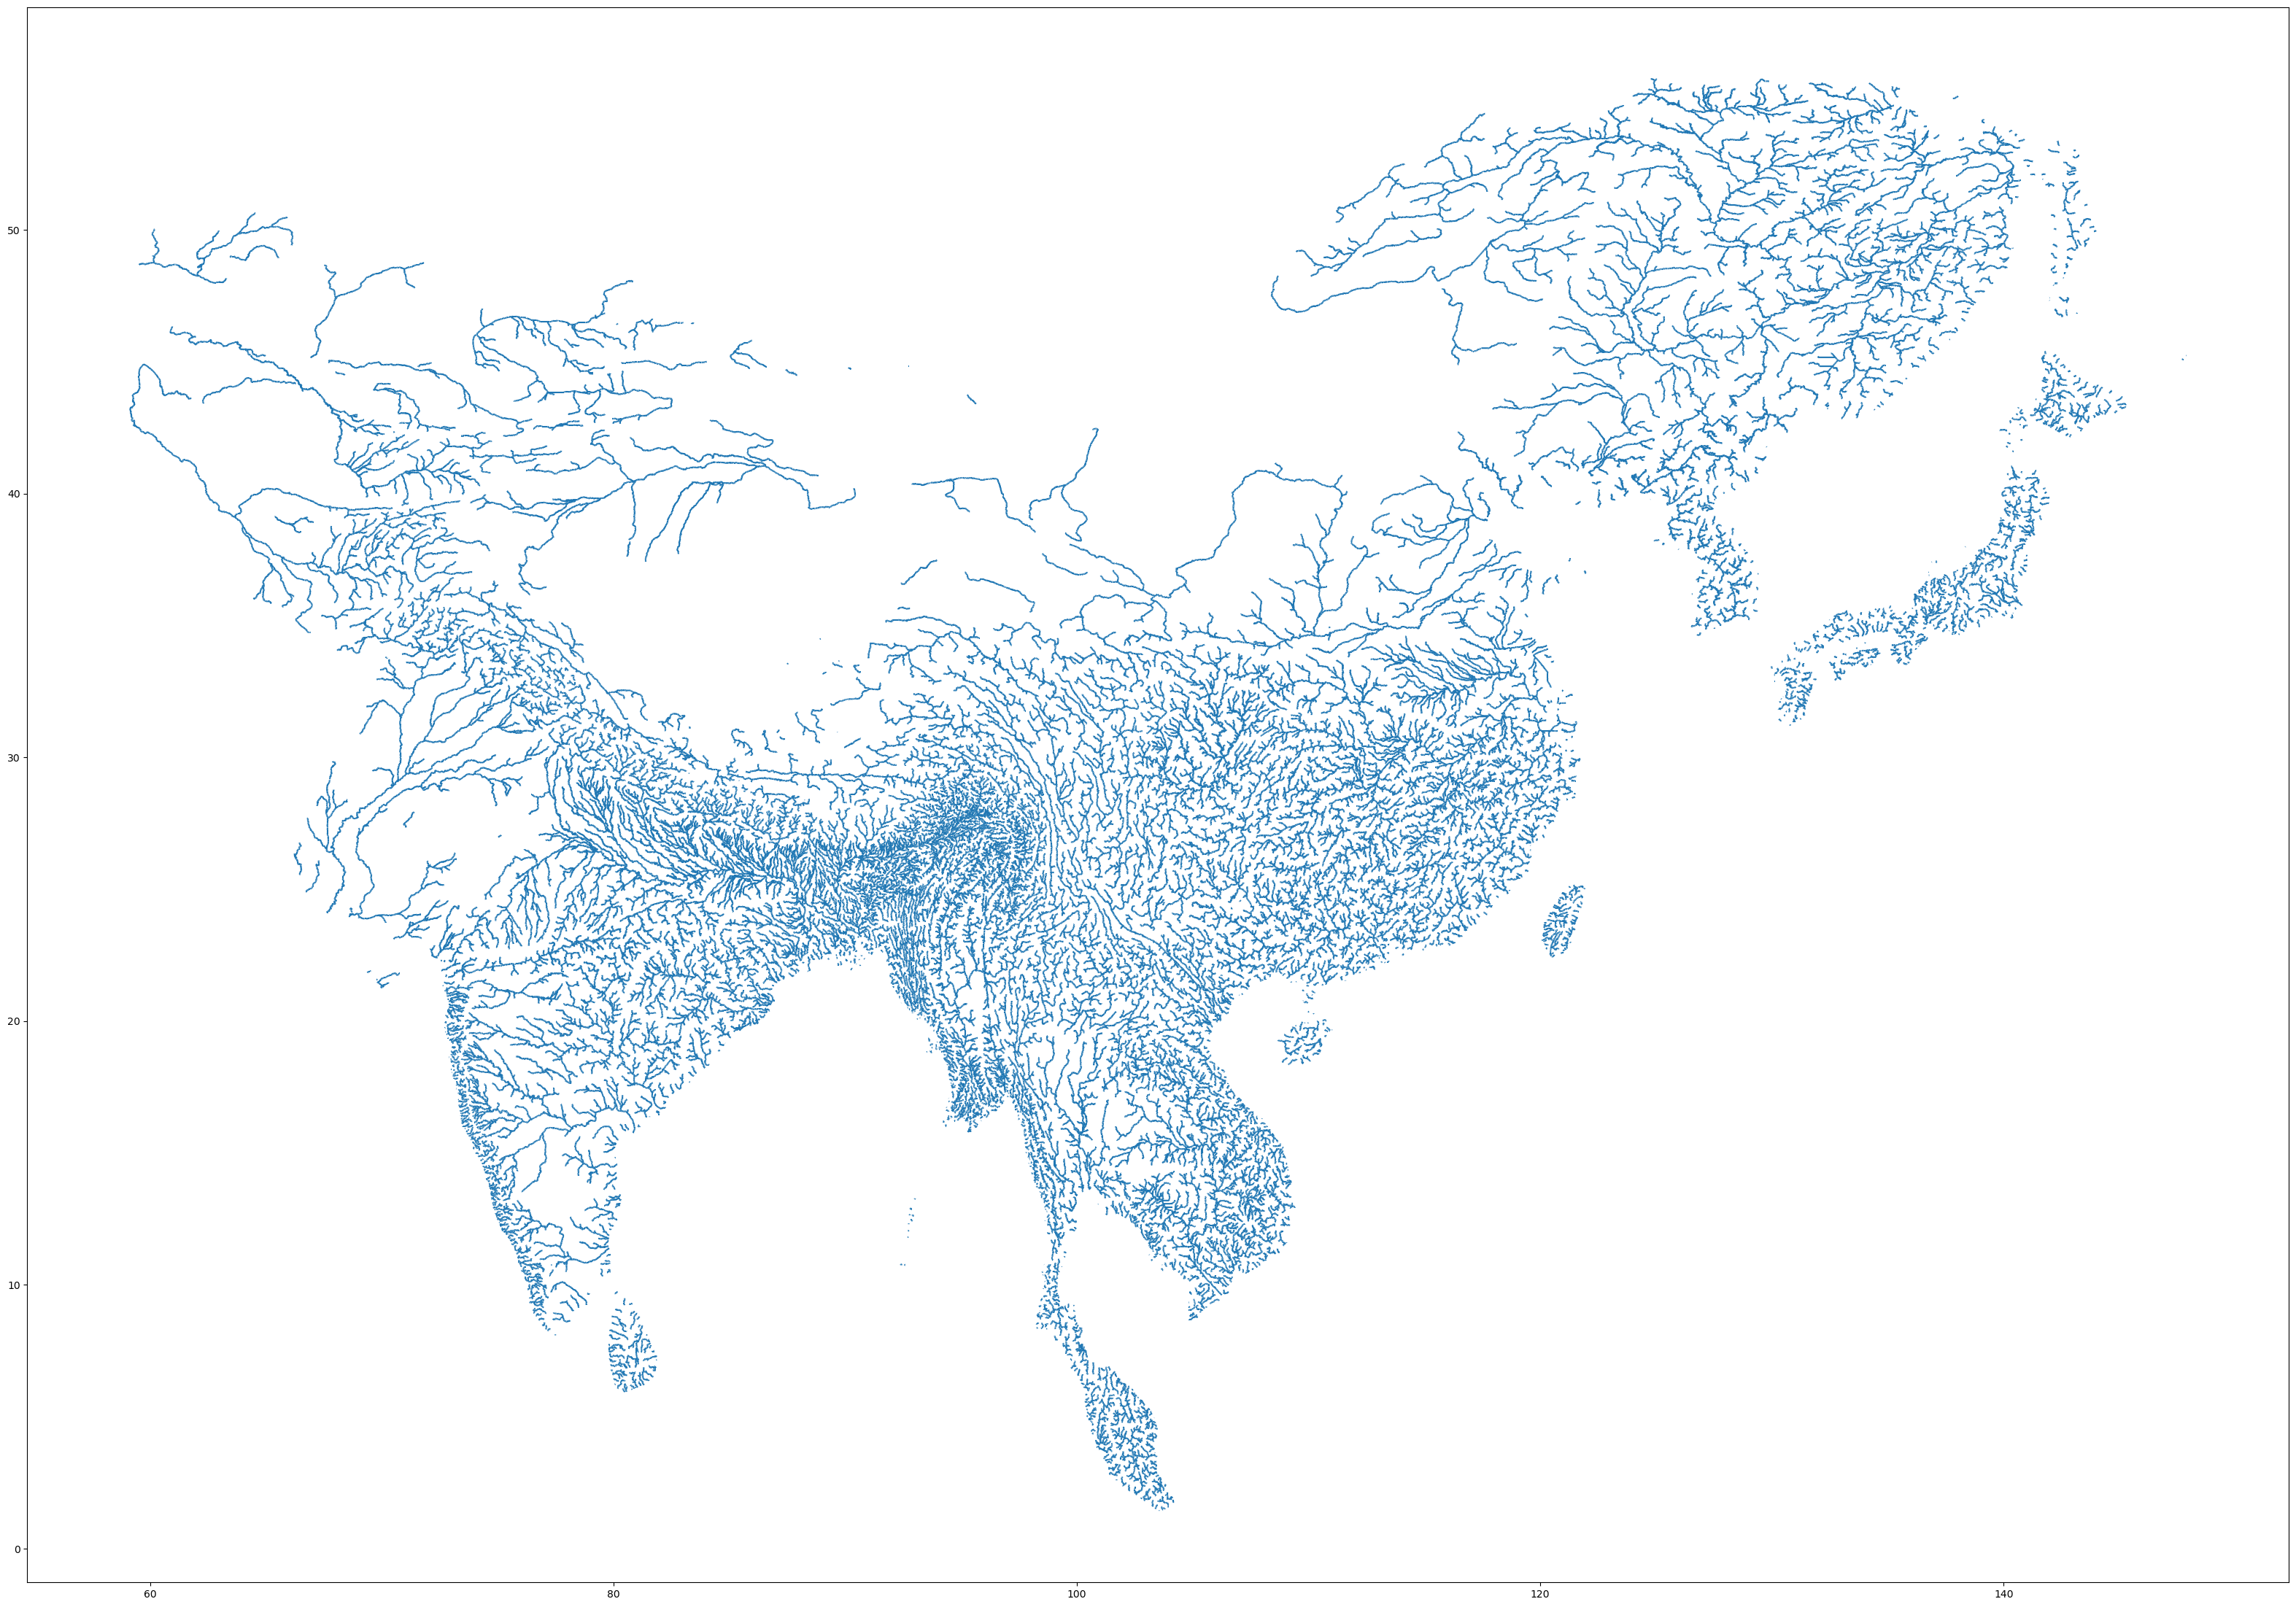

In [4]:
large_rivers = rivers[
    rivers["DIS_AV_CMS"] >= 5
]
large_rivers.plot(figsize=(40,40))

In [ ]:
from shapely.geometry import box
import geopandas as gpd
import matplotlib.pyplot as plt

# 1掳 脳 1掳 study region
lon_min, lat_min, lon_max, lat_max = 116, 30, 117, 31
region = box(lon_min, lat_min, lon_max, lat_max)

# crop rivers
rivers_region = large_rivers[large_rivers.intersects(region)]

ax = gpd.GeoSeries([region], crs=rivers.crs).boundary.plot(
    figsize=(8, 8),
    color="red"
)
rivers_region.plot(ax=ax, linewidth=1)
plt.title("Selected 1掳 脳 1掳 region")
plt.show()

print("Number of river segments:", len(rivers_region))

In [ ]:
import rasterio
from rasterio.windows import from_bounds
import numpy as np
import matplotlib.pyplot as plt

occ_path = "../../Data/occurrence_110E_40Nv1_4_2021.tif"

# 閫変竴涓?1掳脳1掳 鍖哄煙
lon_min, lat_min, lon_max, lat_max = 116, 30, 117, 31

with rasterio.open(occ_path) as src:
    window = from_bounds(
        lon_min, lat_min, lon_max, lat_max,
        transform=src.transform
    )

    occ = src.read(1, window=window)

    # 杩欐椂鏁扮粍宸茬粡寰堝皬锛屽彲浠ヨ浆鎹n
    occ = occ.astype("float32")
    occ[occ == 255] = np.nan

    extent = [lon_min, lon_max, lat_min, lat_max]

print(occ.shape)
print(np.nanmin(occ), np.nanmax(occ))

plt.figure(figsize=(8, 8))
plt.imshow(occ, extent=extent, origin="upper", cmap="Blues")
plt.colorbar(label="Water occurrence (%)")
plt.title("JRC Water Occurrence: 114E鈥?15E, 34N鈥?5N")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [ ]:
season_path = "../../Data/seasonality_110E_40Nv1_4_2021.tif"

with rasterio.open(season_path) as src:
    window = from_bounds(
        lon_min, lat_min, lon_max, lat_max,
        transform=src.transform
    )

    season = src.read(1, window=window)
    season = season.astype("float32")
    season[season == 255] = np.nan

plt.figure(figsize=(8, 8))
plt.imshow(season, extent=extent, origin="upper", cmap="viridis")
plt.colorbar(label="Water months per year")
plt.title("JRC Water Seasonality")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [ ]:
import rasterio
from rasterio.windows import from_bounds
from rasterio.features import geometry_mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box
import pandas as pd

# =========================
# 1. Study region
# =========================
#lon_min, lat_min, lon_max, lat_max = 116, 30, 117, 31
lon_min, lat_min, lon_max, lat_max = 116.6, 30.4, 116.7, 30.5
extent = [lon_min, lon_max, lat_min, lat_max]
region_geom = box(lon_min, lat_min, lon_max, lat_max)

# =========================
# 2. File paths
# =========================
occ_path = "../../Data/occurrence_110E_40Nv1_4_2021.tif"
season_path = "../../Data/seasonality_110E_40Nv1_4_2021.tif"
gdb_path = r"../../Data/Google Earth Engine/HydroRIVERS_v10_as.gdb/HydroRIVERS_v10_as.gdb"

# =========================
# 3. Read JRC raster window
# =========================
def read_jrc_window(path, lon_min, lat_min, lon_max, lat_max):
    with rasterio.open(path) as src:
        window = from_bounds(
            lon_min, lat_min, lon_max, lat_max,
            transform=src.transform
        )

        arr = src.read(1, window=window).astype("float32")
        arr[arr == 255] = np.nan

        transform = src.window_transform(window)
        crs = src.crs

    return arr, transform, crs

occ, occ_transform, raster_crs = read_jrc_window(
    occ_path, lon_min, lat_min, lon_max, lat_max
)

season, season_transform, _ = read_jrc_window(
    season_path, lon_min, lat_min, lon_max, lat_max
)

print("Occurrence shape:", occ.shape)
print("Seasonality shape:", season.shape)
print("Occurrence range:", np.nanmin(occ), np.nanmax(occ))
print("Seasonality range:", np.nanmin(season), np.nanmax(season))

# =========================
# 4. Read HydroRIVERS
# =========================
rivers = gpd.read_file(gdb_path)
rivers = rivers.to_crs(raster_crs)

# 鍏堣鍓埌鐮旂┒鍖洪檮杩慭n
rivers_region_all = rivers[rivers.intersects(region_geom)].copy()

# 绛涢€夎緝澶ф渤娴乗n
# 5 澶綆锛屾渤缃戜細寰堝瘑锛涘缓璁厛鐢?100 鎴?500
rivers_region = rivers_region_all[
    rivers_region_all["DIS_AV_CMS"] >= 5
].copy()

print("All river segments in region:", len(rivers_region_all))
print("Large river segments in region:", len(rivers_region))

# =========================
# 5. Create river buffer
# =========================
# buffer 蹇呴』鍦ㄧ背鍒舵姇褰变笅鍋歕n
rivers_m = rivers_region.to_crs(epsg=3857).copy()
rivers_m["geometry"] = rivers_m.geometry.buffer(300)  # 300 m buffer

river_buffer = rivers_m.to_crs(raster_crs).copy()

# =========================
# 6. Function: calculate mean raster value in each buffer
# =========================
def zonal_mean_for_each_feature(raster_arr, transform, features_gdf, value_name):
    results = []

    for idx, row in features_gdf.iterrows():
        geom = row.geometry

        mask = geometry_mask(
            [geom],
            out_shape=raster_arr.shape,
            transform=transform,
            invert=True
        )

        values = raster_arr[mask]
        values = values[~np.isnan(values)]

        if len(values) == 0:
            mean_val = np.nan
            max_val = np.nan
            valid_pixels = 0
        else:
            mean_val = float(np.mean(values))
            max_val = float(np.max(values))
            valid_pixels = int(len(values))

        results.append({
            "index": idx,
            f"mean_{value_name}": mean_val,
            f"max_{value_name}": max_val,
            f"valid_pixels_{value_name}": valid_pixels
        })

    return pd.DataFrame(results)

occ_stats = zonal_mean_for_each_feature(
    occ, occ_transform, river_buffer, "occurrence"
)

season_stats = zonal_mean_for_each_feature(
    season, season_transform, river_buffer, "seasonality"
)

# =========================
# 7. Merge stats back to rivers
# =========================
stats = occ_stats.merge(season_stats, on="index", how="left")

rivers_result = rivers_region.copy()
rivers_result["index"] = rivers_result.index
rivers_result = rivers_result.merge(stats, on="index", how="left")

# =========================
# 8. Simple classification
# =========================
def classify(row):
    occ_mean = row["mean_occurrence"]
    seas_mean = row["mean_seasonality"]

    if pd.isna(occ_mean) or occ_mean < 1:
        return "not observable"

    if seas_mean >= 10:
        return "perennial-like"

    if 2 <= seas_mean < 10:
        return "intermittent-like"

    if 0 < seas_mean < 2:
        return "ephemeral-like"

    return "uncertain"

rivers_result["class"] = rivers_result.apply(classify, axis=1)

# =========================
# 9. Plot occurrence + river centerlines
# =========================
fig, ax = plt.subplots(figsize=(8, 6), dpi=200)

im = ax.imshow(
    occ,
    extent=extent,
    origin="upper",
    cmap="",
    vmin=0,
    vmax=100
)

rivers_region.plot(
    ax=ax,
    color="red",
    linewidth=1
)

plt.colorbar(im, ax=ax, label="Water occurrence (%)",shrink=0.6)
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
ax.set_title("JRC Water Occurrence + HydroRIVERS")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

# =========================
# 10. Plot seasonality + river centerlines
# =========================
fig, ax = plt.subplots(figsize=(8, 6), dpi=200)

im = ax.imshow(
    season,
    extent=extent,
    origin="upper",
    cmap="viridis",
    vmin=0,
    vmax=12
)

rivers_region.plot(
    ax=ax,
    color="red",
    linewidth=1
)

plt.colorbar(im, ax=ax, label="Water months per year", shrink=0.6)
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
ax.set_title("JRC Water Seasonality + HydroRIVERS")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

# =========================
# 11. Plot classified rivers
# =========================
fig, ax = plt.subplots(figsize=(8, 6), dpi=200)

im = ax.imshow(
    season,
    extent=extent,
    origin="upper",
    cmap="viridis",
    vmin=0,
    vmax=12
)

rivers_result.plot(
    ax=ax,
    column="class",
    legend=True,
    linewidth=2
)

plt.colorbar(im, ax=ax, label="Water months per year", shrink=0.6)
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
ax.set_title("River classification based on JRC seasonality")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8), dpi=400)

im = ax.imshow(
    season,
    extent=extent,
    origin="upper",
    cmap="viridis",
    vmin=0,
    vmax=12
)

rivers_result.plot(
    ax=ax,
    column="class",
    legend=True,
    linewidth=2
)
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
plt.colorbar(im, ax=ax, label="Water months per year")
ax.set_title("River classification based on JRC seasonality")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=200)

im = ax.imshow(
    occ,
    extent=extent,
    origin="upper",
    cmap="jet",
    vmin=0,
    vmax=100
)

rivers_region.plot(
    ax=ax,
    color="red",
    linewidth=1
)

plt.colorbar(im, ax=ax, label="Water occurrence (%)",shrink=0.6)
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
ax.set_title("JRC Water Occurrence + HydroRIVERS")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()
